In [1]:
# All necessary imports for Grad-CAM visualization
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

import json
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
# Load class mapping and model weights
model_path = '../models/resnet18_brain_tumor_weights.pth'
metadata_path = '../data/processed/preprocessing_metadata.json'

with open(metadata_path, 'r') as f:
    metadata = json.load(f)
class_mapping = metadata['class_mapping']
classes = [class_mapping[str(i)] for i in range(len(class_mapping))]

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(weights=None)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = nn.Linear(512, len(classes))
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

/var/folders/bz/l_61zlvj34gcp1c8znmr81rr0000gn/T/ipykernel_68754/3064665665.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path,

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
import json

dataset_path = '../data/processed'

metadata_path = os.path.join(dataset_path, 'preprocessing_metadata.json')
if not os.path.exists(metadata_path):
    raise FileNotFoundError(f"Metadata file not found: {metadata_path}")

try:
    with open(metadata_path, 'r') as f:
        preprocessing_metadata = json.load(f)
except json.JSONDecodeError as e:
    raise ValueError(f"Error decoding JSON from {metadata_path}: {e}")

# read in pixel mean and std for normalization
train_mean = preprocessing_metadata['normalization']['mean']
train_std = preprocessing_metadata['normalization']['std']

In [15]:
# Grad-CAM setup
target_layer = model.layer4[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

# Define image transform (should match training)
transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize((train_mean,), (train_std,))
])


# Example: produce Grad-CAM for several images in validation set
split_dir = '../data/processed/Testing/' 
class_list = [token for token in os.listdir(split_dir) if 'tumor' in token]

correct_images_by_class_index = []
incorrect_images_by_class_index = []

# loop through each class
for class_name in class_list:
    print(class_name)
    image_dir = os.path.join(split_dir, class_name)
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

    correct_images = []
    incorrect_images = []

    for image_file in image_files:
        image_path = os.path.join(image_dir, image_file)
        img = Image.open(image_path).convert('L')
        input_tensor = transform(img).unsqueeze(0).to(device)
        outputs = model(input_tensor)
        pred_idx = outputs.argmax(dim=1).item()
        pred_label = classes[pred_idx]
        true_label = class_name

        if pred_label==true_label:
            correct_images.append(image_path)
        else:
            incorrect_images.append(image_path)
    

    correct_images_by_class_index.append(correct_images)
    incorrect_images_by_class_index.append(incorrect_images)


no_tumor
meningioma_tumor
glioma_tumor
pituitary_tumor


In [16]:
# show lengths of each list
for i in range(len(correct_images_by_class_index)):
    class_name = class_list[i]
    n = len(correct_images_by_class_index[i])
    m = len(incorrect_images_by_class_index[i])
    print(f"Class {class_name} has {n} correctly identified images and {m} incorrectly identified.")

Class no_tumor has 105 correctly identified images and 3 incorrectly identified.
Class meningioma_tumor has 127 correctly identified images and 16 incorrectly identified.
Class glioma_tumor has 137 correctly identified images and 50 incorrectly identified.
Class pituitary_tumor has 144 correctly identified images and 5 incorrectly identified.


In [ ]:
def show_gradcam_comparison(model, cam, image_path_correct, image_path_incorrect, transform, classes, class_name):
    """
    Visualize Grad-CAM for one correctly and one incorrectly classified image side by side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for idx, image_path in enumerate([image_path_correct, image_path_incorrect]):
        img = Image.open(image_path).convert('L')
        input_tensor = transform(img).unsqueeze(0).to(next(model.parameters()).device)
        # Grad-CAM expects 3-channel input, so stack grayscale to 3 channels
        rgb_img = np.stack([np.array(img)/255.]*3, axis=-1)
        # Get prediction
        outputs = model(input_tensor)
        pred_idx = outputs.argmax(dim=1).item()
        pred_label = classes[pred_idx]
        # Grad-CAM
        grayscale_cam = cam(input_tensor)[0]
        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        axes[idx].imshow(cam_image)
        axes[idx].set_title(
            f"{'Correct' if idx==0 else 'Incorrect'}\nTrue: {class_name}\nPred: {pred_label}"
        )
        axes[idx].axis('off')
    plt.suptitle(f"Grad-CAM Comparison for {class_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

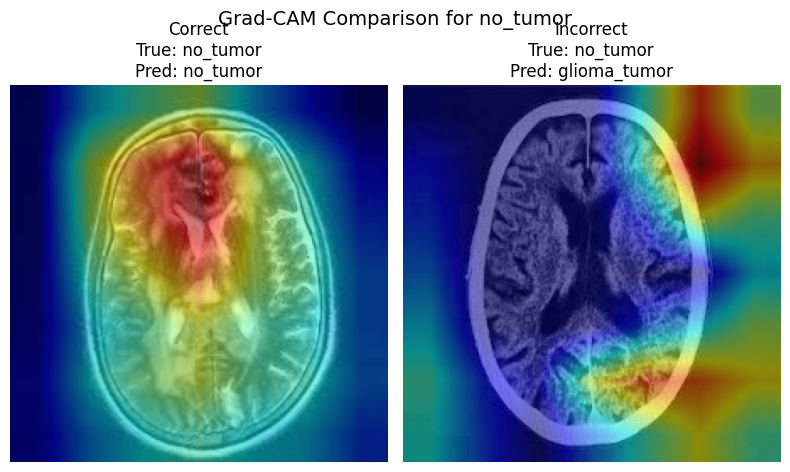

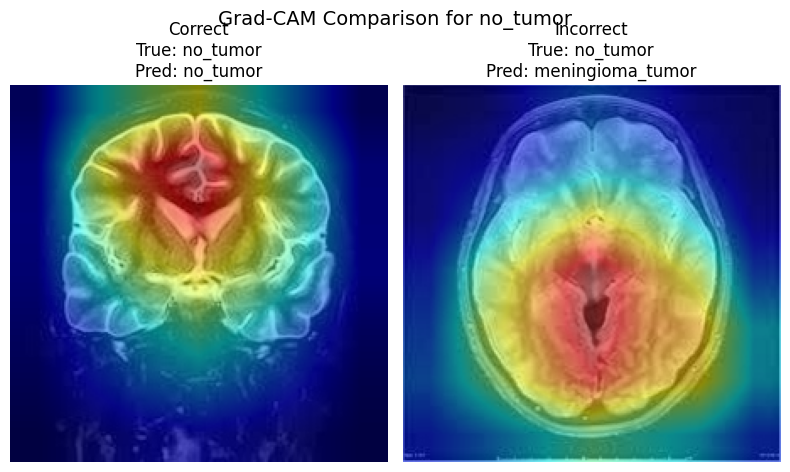

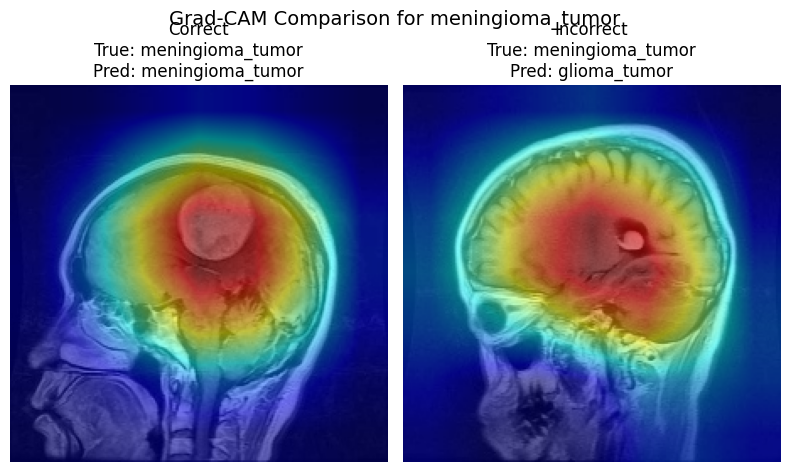

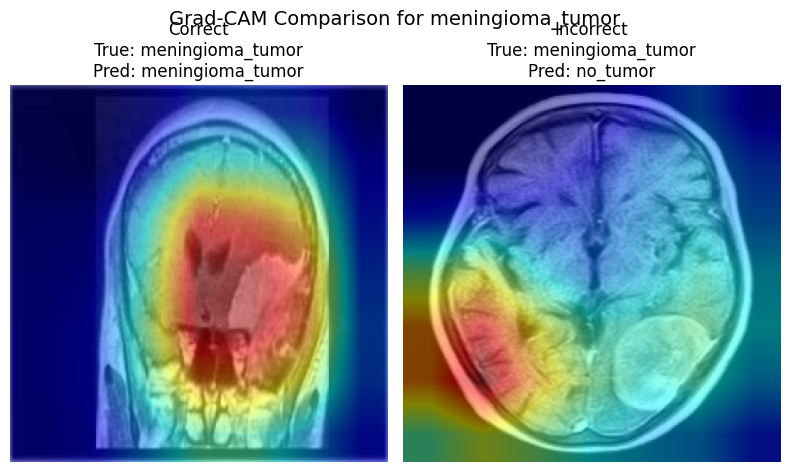

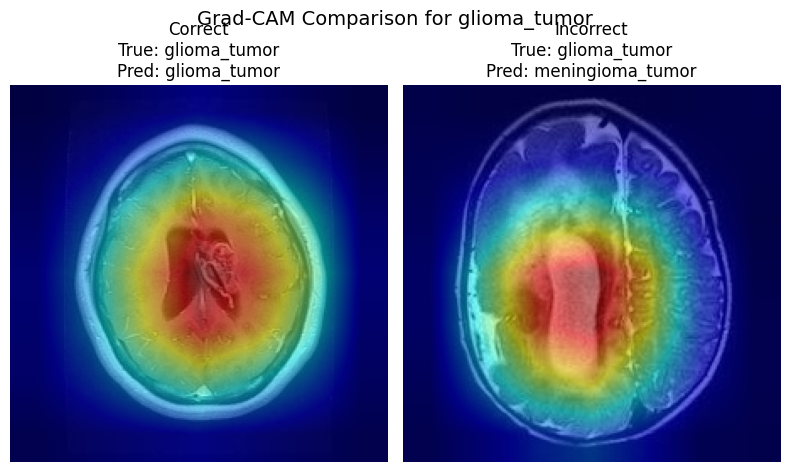

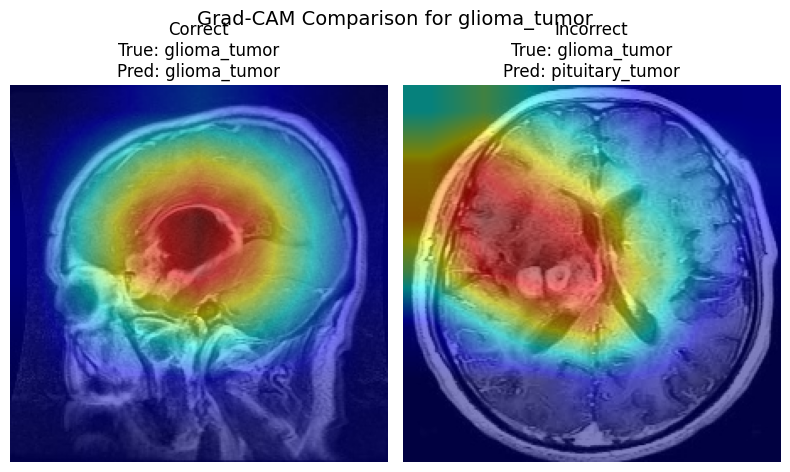

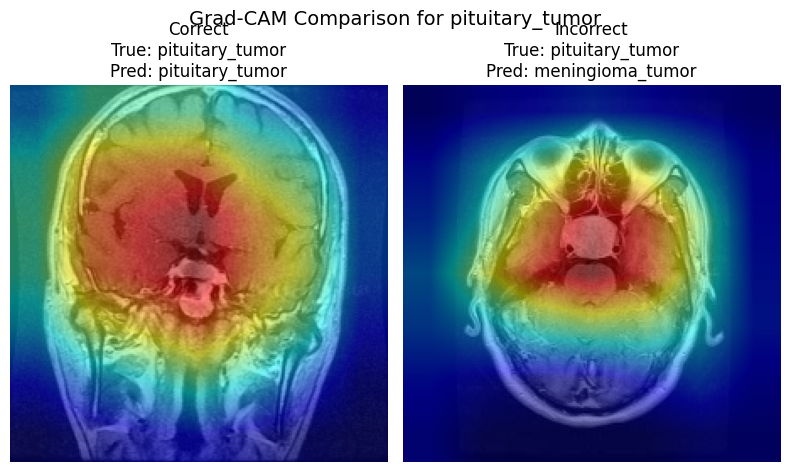

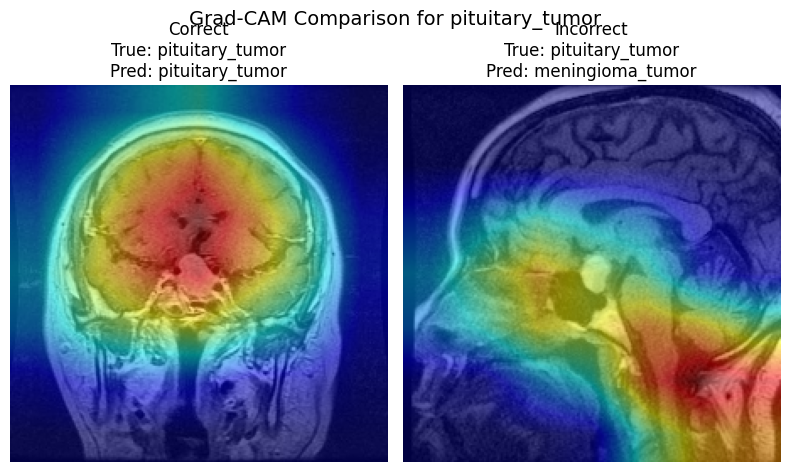

In [28]:
# For class_index in range(len(class_list)):
# Pick one correct and one incorrect image for each class

for class_index in range(len(class_list)):

    if correct_images_by_class_index[class_index] and incorrect_images_by_class_index[class_index]:

        for i in range(2):
            show_gradcam_comparison(
                model, cam,
                correct_images_by_class_index[class_index][i],
                incorrect_images_by_class_index[class_index][i],
                transform, classes, class_list[class_index]
            )